# Actividad 4.1 – Proyecto integrador de modelado estadístico para Big Data

## Análisis de agrupamiento del conjunto de datos Covertype

### Pregunta de análisis

¿Qué estructuras de agrupación pueden identificarse a partir de las características cartográficas y qué tan confiables y útiles resultan los grupos obtenidos?

### Objetivo

Identificar estructuras de agrupamiento presentes en las características cartográficas del conjunto de datos Covertype mediante técnicas de reducción de dimensionalidad y aprendizaje no supervisado.

Para ello se utilizará Análisis de Componentes Principales (PCA) y MiniBatch K-Means. La variable `Cover_Type` se reservará exclusivamente para la validación externa del modelo y no participará en el preprocesamiento, construcción ni selección de los grupos.

In [1]:
# ============================================================
# PARTE 1 - CARGA Y ORGANIZACIÓN DE LOS DATOS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import fetch_covtype

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

# Cargar Covertype como DataFrame
covtype = fetch_covtype(as_frame=True)

df = covtype.frame.copy()

print("\nDataset cargado correctamente.")
print("Dimensiones:", df.shape)

df.head()

NumPy: 2.3.5
Pandas: 2.3.3
Scikit-learn: 1.7.2

Dataset cargado correctamente.
Dimensiones: (581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


In [2]:
# ============================================================
# 1.1 INSPECCIÓN INICIAL DEL DATASET
# ============================================================

print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET COVERTYPE")
print("=" * 60)

print(f"\nNúmero de observaciones: {df.shape[0]:,}")
print(f"Número de variables: {df.shape[1]}")

print("\nPrimeras 5 observaciones:")
display(df.head())

print("\nTipos de datos:")
print(df.dtypes.value_counts())

print("\nValores faltantes:")
print(f"Total de valores faltantes: {df.isnull().sum().sum():,}")

print("\nRegistros duplicados:")
print(f"Total de duplicados: {df.duplicated().sum():,}")

memoria_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print("\nConsumo de memoria:")
print(f"{memoria_mb:.2f} MB")

INFORMACIÓN GENERAL DEL DATASET COVERTYPE

Número de observaciones: 581,012
Número de variables: 55

Primeras 5 observaciones:


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5



Tipos de datos:
float64    54
int32       1
Name: count, dtype: int64

Valores faltantes:
Total de valores faltantes: 0

Registros duplicados:
Total de duplicados: 0

Consumo de memoria:
241.59 MB


In [3]:
# ============================================================
# 1.2 SEPARACIÓN DE LA VARIABLE RESERVADA Cover_Type
# ============================================================

# Cover_Type se reserva exclusivamente para validación externa
y_external = df["Cover_Type"].copy()

# Variables que sí podrán utilizarse para el agrupamiento
X = df.drop(columns=["Cover_Type"]).copy()

print("=" * 60)
print("SEPARACIÓN DE Cover_Type")
print("=" * 60)

print(f"\nDimensiones del dataset original: {df.shape}")
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y_external: {y_external.shape}")

print("\n¿Cover_Type está dentro de X?")
print("Cover_Type" in X.columns)

print("\nNúmero de variables disponibles para clustering:")
print(X.shape[1])

print("\nValores de Cover_Type reservados:")
print(sorted(y_external.unique()))

print("\nDistribución de Cover_Type:")
print(y_external.value_counts().sort_index())

SEPARACIÓN DE Cover_Type

Dimensiones del dataset original: (581012, 55)
Dimensiones de X: (581012, 54)
Dimensiones de y_external: (581012,)

¿Cover_Type está dentro de X?
False

Número de variables disponibles para clustering:
54

Valores de Cover_Type reservados:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7)]

Distribución de Cover_Type:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


### Separación de la variable `Cover_Type`

La variable `Cover_Type` fue separada del conjunto de características antes de realizar cualquier procedimiento de transformación, escalamiento, reducción de dimensionalidad o agrupamiento.

El conjunto original contiene 55 variables. Después de reservar `Cover_Type`, la matriz de características `X` contiene 54 variables cartográficas.

`Cover_Type` se almacenó de manera independiente en `y_external` y no será utilizada para construir ni seleccionar los grupos. Su utilización se limitará a la etapa final de validación externa, con el propósito de analizar la correspondencia entre los grupos obtenidos y las clases conocidas.

In [4]:
# ============================================================
# 2.1 IDENTIFICACIÓN DE VARIABLES CUANTITATIVAS Y BINARIAS
# ============================================================

# Una variable se considera binaria si sus únicos valores
# observados pertenecen al conjunto {0, 1}
binary_cols = [
    col for col in X.columns
    if set(X[col].dropna().unique()).issubset({0, 1})
]

# El resto se considera cuantitativo
quantitative_cols = [
    col for col in X.columns
    if col not in binary_cols
]

print("=" * 60)
print("CLASIFICACIÓN DE VARIABLES")
print("=" * 60)

print(f"\nVariables cuantitativas: {len(quantitative_cols)}")
for col in quantitative_cols:
    print(f" - {col}")

print(f"\nVariables binarias: {len(binary_cols)}")
for col in binary_cols:
    print(f" - {col}")

print("\nComprobación:")
print(f"Cuantitativas + binarias = "
      f"{len(quantitative_cols) + len(binary_cols)}")

print(f"Total de columnas de X = {X.shape[1]}")

CLASIFICACIÓN DE VARIABLES

Variables cuantitativas: 10
 - Elevation
 - Aspect
 - Slope
 - Horizontal_Distance_To_Hydrology
 - Vertical_Distance_To_Hydrology
 - Horizontal_Distance_To_Roadways
 - Hillshade_9am
 - Hillshade_Noon
 - Hillshade_3pm
 - Horizontal_Distance_To_Fire_Points

Variables binarias: 44
 - Wilderness_Area_0
 - Wilderness_Area_1
 - Wilderness_Area_2
 - Wilderness_Area_3
 - Soil_Type_0
 - Soil_Type_1
 - Soil_Type_2
 - Soil_Type_3
 - Soil_Type_4
 - Soil_Type_5
 - Soil_Type_6
 - Soil_Type_7
 - Soil_Type_8
 - Soil_Type_9
 - Soil_Type_10
 - Soil_Type_11
 - Soil_Type_12
 - Soil_Type_13
 - Soil_Type_14
 - Soil_Type_15
 - Soil_Type_16
 - Soil_Type_17
 - Soil_Type_18
 - Soil_Type_19
 - Soil_Type_20
 - Soil_Type_21
 - Soil_Type_22
 - Soil_Type_23
 - Soil_Type_24
 - Soil_Type_25
 - Soil_Type_26
 - Soil_Type_27
 - Soil_Type_28
 - Soil_Type_29
 - Soil_Type_30
 - Soil_Type_31
 - Soil_Type_32
 - Soil_Type_33
 - Soil_Type_34
 - Soil_Type_35
 - Soil_Type_36
 - Soil_Type_37
 - Soil_Typ

### Clasificación de las variables

Las características utilizadas para el agrupamiento se dividieron en
variables cuantitativas y variables binarias.

Las variables cuantitativas representan características cartográficas
medidas en diferentes escalas, por lo que requieren un procedimiento de
escalamiento antes de aplicar algoritmos basados en distancia.

Las variables binarias representan indicadores de pertenencia o
ausencia/presencia, correspondientes principalmente a áreas silvestres
y tipos de suelo. Estas variables se conservarán en su codificación
0/1 para mantener su interpretación original.

Esta distinción permite evitar que las diferencias de escala entre las
variables cuantitativas dominen artificialmente el cálculo de las
distancias durante el agrupamiento.

In [5]:
# ============================================================
# 2.2 ESCALAMIENTO Y CONFIGURACIÓN DE REFERENCIA
# ============================================================

from sklearn.preprocessing import StandardScaler
import time

# Medir tiempo del procesamiento
inicio = time.perf_counter()

# Copia para no modificar X original
X_reference = X.copy()

# Crear escalador
scaler = StandardScaler()

# Escalar solamente las variables cuantitativas
X_reference[quantitative_cols] = scaler.fit_transform(
    X_reference[quantitative_cols]
)

tiempo_escalamiento = time.perf_counter() - inicio

# Memoria utilizada
memoria_reference_mb = (
    X_reference.memory_usage(deep=True).sum() / (1024 ** 2)
)

print("=" * 60)
print("CONFIGURACIÓN DE REFERENCIA SIN PCA")
print("=" * 60)

print(f"\nDimensiones: {X_reference.shape}")
print(f"Número de características: {X_reference.shape[1]}")
print(f"Tiempo de escalamiento: {tiempo_escalamiento:.4f} segundos")
print(f"Memoria utilizada: {memoria_reference_mb:.2f} MB")

print("\nComprobación de Cover_Type:")
print("¿Cover_Type está presente?", "Cover_Type" in X_reference.columns)

CONFIGURACIÓN DE REFERENCIA SIN PCA

Dimensiones: (581012, 54)
Número de características: 54
Tiempo de escalamiento: 0.4638 segundos
Memoria utilizada: 239.37 MB

Comprobación de Cover_Type:
¿Cover_Type está presente? False


In [6]:
# ============================================================
# 2.3 COMPROBACIÓN DEL ESCALAMIENTO
# ============================================================

print("=" * 60)
print("COMPROBACIÓN DEL ESCALAMIENTO")
print("=" * 60)

resumen_escalamiento = pd.DataFrame({
    "Media": X_reference[quantitative_cols].mean(),
    "Desviación estándar": X_reference[quantitative_cols].std(ddof=0)
})

display(resumen_escalamiento.round(4))

print("\nValores únicos de algunas variables binarias:")

for col in binary_cols[:5]:
    print(f"{col}: {sorted(X_reference[col].unique())}")

COMPROBACIÓN DEL ESCALAMIENTO


,Media,Desviación estándar
Elevation,-0.0,1.0
Aspect,-0.0,1.0
Slope,0.0,1.0
Horizontal_Distance_To_Hydrology,-0.0,1.0
Vertical_Distance_To_Hydrology,0.0,1.0
Horizontal_Distance_To_Roadways,0.0,1.0
Hillshade_9am,0.0,1.0
Hillshade_Noon,0.0,1.0
Hillshade_3pm,-0.0,1.0
Horizontal_Distance_To_Fire_Points,0.0,1.0



Valores únicos de algunas variables binarias:
Wilderness_Area_0: [np.float64(0.0), np.float64(1.0)]
Wilderness_Area_1: [np.float64(0.0), np.float64(1.0)]
Wilderness_Area_2: [np.float64(0.0), np.float64(1.0)]
Wilderness_Area_3: [np.float64(0.0), np.float64(1.0)]
Soil_Type_0: [np.float64(0.0), np.float64(1.0)]


### Escalamiento y configuración de referencia

Se aplicó `StandardScaler` exclusivamente a las diez variables
cuantitativas. Este procedimiento transforma cada característica para
obtener aproximadamente media cero y desviación estándar uno.

El escalamiento es necesario debido a que MiniBatch K-Means utiliza
distancias para formar los grupos. Sin esta transformación, variables
con magnitudes elevadas, como elevación o distancias horizontales,
podrían ejercer una influencia desproporcionada sobre el agrupamiento.

Las 44 variables binarias se conservaron en su codificación original
0/1, preservando su interpretación como indicadores de ausencia o
presencia.

La matriz resultante constituye la configuración de referencia sin
reducción de dimensionalidad. Esta representación será comparada
posteriormente con la obtenida mediante PCA en términos de número de
variables, información conservada, tiempo de procesamiento, memoria y
calidad del agrupamiento.

La variable `Cover_Type` permanece excluida de todas las
transformaciones y procedimientos de agrupamiento.

In [7]:
# ============================================================
# 3.1 PCA - VARIANZA EXPLICADA ACUMULADA
# ============================================================

from sklearn.decomposition import PCA
import numpy as np
import time

inicio_pca = time.perf_counter()

# PCA completo para estudiar la varianza explicada
pca_full = PCA(random_state=42)

pca_full.fit(X_reference)

tiempo_pca_full = time.perf_counter() - inicio_pca

# Varianza explicada
varianza_individual = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_individual)

# Número de componentes necesarios para diferentes umbrales
n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
n_90 = np.argmax(varianza_acumulada >= 0.90) + 1
n_95 = np.argmax(varianza_acumulada >= 0.95) + 1

print("=" * 60)
print("ANÁLISIS DE VARIANZA EXPLICADA")
print("=" * 60)

print(f"\nComponentes originales: {X_reference.shape[1]}")
print(f"Componentes para alcanzar 80%: {n_80}")
print(f"Componentes para alcanzar 90%: {n_90}")
print(f"Componentes para alcanzar 95%: {n_95}")

print(f"\nTiempo de ajuste PCA completo: {tiempo_pca_full:.4f} segundos")

print("\nVarianza acumulada alcanzada:")
print(f"Con {n_80} componentes: {varianza_acumulada[n_80-1]:.4f}")
print(f"Con {n_90} componentes: {varianza_acumulada[n_90-1]:.4f}")
print(f"Con {n_95} componentes: {varianza_acumulada[n_95-1]:.4f}")

ANÁLISIS DE VARIANZA EXPLICADA

Componentes originales: 54
Componentes para alcanzar 80%: 7
Componentes para alcanzar 90%: 10
Componentes para alcanzar 95%: 14

Tiempo de ajuste PCA completo: 0.5762 segundos

Varianza acumulada alcanzada:
Con 7 componentes: 0.8346
Con 10 componentes: 0.9224
Con 14 componentes: 0.9551


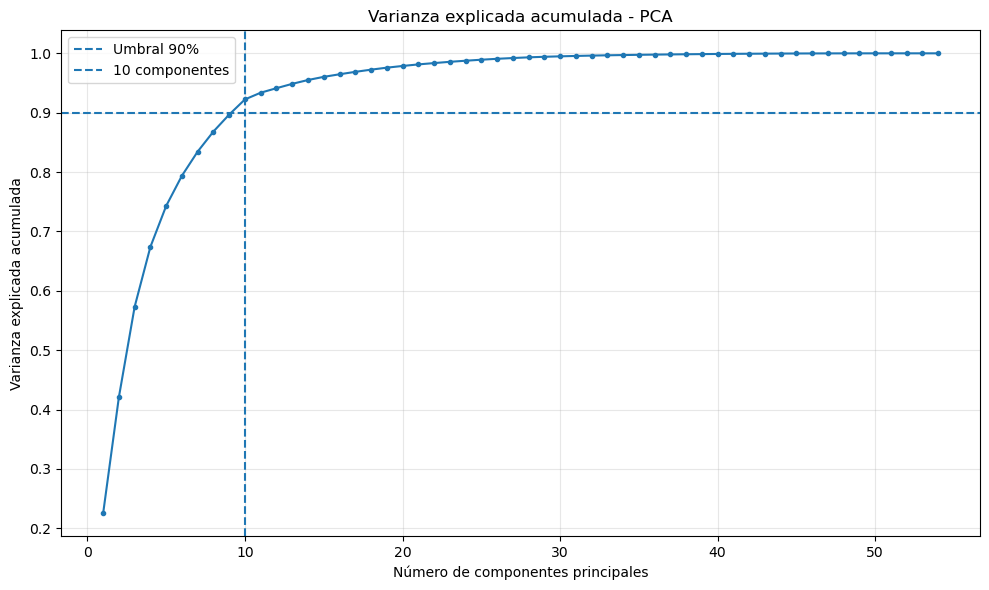

In [8]:
# ============================================================
# 3.2 GRÁFICA DE VARIANZA EXPLICADA ACUMULADA
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker="o",
    markersize=3
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="Umbral 90%"
)

plt.axvline(
    x=n_90,
    linestyle="--",
    label=f"{n_90} componentes"
)

plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada - PCA")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [9]:
# ============================================================
# 3.3 REPRESENTACIÓN REDUCIDA CON PCA
# ============================================================

from sklearn.decomposition import PCA
import pandas as pd
import time

# Número seleccionado a partir del umbral del 90%
n_components_selected = n_90

inicio = time.perf_counter()

pca = PCA(
    n_components=n_components_selected,
    random_state=42
)

X_pca_array = pca.fit_transform(X_reference)

tiempo_transformacion_pca = time.perf_counter() - inicio

# Convertir a DataFrame
columnas_pca = [
    f"PC{i}" for i in range(1, n_components_selected + 1)
]

X_pca = pd.DataFrame(
    X_pca_array,
    columns=columnas_pca,
    index=X_reference.index
)

# Memoria
memoria_pca_mb = X_pca.memory_usage(deep=True).sum() / (1024 ** 2)

# Varianza total conservada
varianza_pca = pca.explained_variance_ratio_.sum()

print("=" * 60)
print("REPRESENTACIÓN REDUCIDA CON PCA")
print("=" * 60)

print(f"\nDimensiones originales: {X_reference.shape}")
print(f"Dimensiones después de PCA: {X_pca.shape}")

print(f"\nComponentes seleccionados: {n_components_selected}")
print(f"Varianza explicada conservada: {varianza_pca:.4f}")
print(f"Varianza explicada (%): {varianza_pca * 100:.2f}%")

print(f"\nTiempo PCA: {tiempo_transformacion_pca:.4f} segundos")
print(f"Memoria representación original: {memoria_reference_mb:.2f} MB")
print(f"Memoria representación PCA: {memoria_pca_mb:.2f} MB")

reduccion_variables = (
    1 - n_components_selected / X_reference.shape[1]
) * 100

reduccion_memoria = (
    1 - memoria_pca_mb / memoria_reference_mb
) * 100

print(f"\nReducción del número de variables: {reduccion_variables:.2f}%")
print(f"Reducción aproximada de memoria: {reduccion_memoria:.2f}%")

print("\nPrimeras observaciones:")
display(X_pca.head())

REPRESENTACIÓN REDUCIDA CON PCA

Dimensiones originales: (581012, 54)
Dimensiones después de PCA: (581012, 10)

Componentes seleccionados: 10
Varianza explicada conservada: 0.9224
Varianza explicada (%): 92.24%

Tiempo PCA: 0.5931 segundos
Memoria representación original: 239.37 MB
Memoria representación PCA: 44.33 MB

Reducción del número de variables: 81.48%
Reducción aproximada de memoria: 81.48%

Primeras observaciones:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-0.841423,-1.629486,-1.063561,0.666986,-3.284042,-1.384440,-0.612622,0.205920,0.118507,0.291035
1,-0.731296,-1.701253,-1.337872,0.570520,-3.283292,-1.411714,-0.614433,0.179704,0.214556,0.260501
2,-0.470700,-2.034066,0.178756,1.284673,-2.423122,-0.560580,0.729497,-0.412029,0.156988,-0.291206
3,-0.688059,-1.208239,0.826084,1.658991,-2.341203,-0.451963,1.627455,-0.905774,0.633876,-0.070904
4,-0.830568,-1.660451,-1.445043,0.604545,-3.205719,-1.388415,-0.641244,0.072060,0.422335,0.149157


In [10]:
# ============================================================
# 3.4 CARGAS DE LOS COMPONENTES PRINCIPALES
# ============================================================

cargas_pca = pd.DataFrame(
    pca.components_.T,
    index=X_reference.columns,
    columns=columnas_pca
)

print("=" * 60)
print("VARIABLES CON MAYOR CONTRIBUCIÓN POR COMPONENTE")
print("=" * 60)

for componente in columnas_pca:
    
    top_variables = (
        cargas_pca[componente]
        .abs()
        .sort_values(ascending=False)
        .head(5)
    )
    
    print(f"\n{componente}:")
    
    for variable in top_variables.index:
        carga = cargas_pca.loc[variable, componente]
        print(f"  {variable:<45} {carga:>8.4f}")

VARIABLES CON MAYOR CONTRIBUCIÓN POR COMPONENTE

PC1:
  Hillshade_3pm                                   0.5931
  Aspect                                          0.4992
  Hillshade_9am                                  -0.4701
  Hillshade_Noon                                  0.3598
  Horizontal_Distance_To_Hydrology                0.1041

PC2:
  Slope                                           0.5091
  Horizontal_Distance_To_Roadways                -0.4065
  Hillshade_Noon                                 -0.3628
  Elevation                                      -0.3589
  Horizontal_Distance_To_Fire_Points             -0.3407

PC3:
  Horizontal_Distance_To_Hydrology                0.6452
  Vertical_Distance_To_Hydrology                  0.6080
  Elevation                                       0.3537
  Horizontal_Distance_To_Roadways                 0.1396
  Slope                                           0.1367

PC4:
  Horizontal_Distance_To_Fire_Points              0.5182
  Horizontal_Dis

### Selección del número de componentes

El análisis de varianza explicada acumulada mostró que 7 componentes
conservan aproximadamente el 83.46 % de la varianza, 10 componentes
alcanzan el 92.24 % y 14 componentes conservan el 95.51 %.

Se seleccionaron 10 componentes principales utilizando como criterio
un umbral mínimo del 90 % de varianza explicada. Esta configuración
permite reducir la representación de 54 a 10 dimensiones, equivalente
a una reducción aproximada del 81.5 % en el número de características,
mientras se conserva más del 92 % de la variabilidad presente en la
representación procesada.

La elección busca un equilibrio entre conservación de información,
reducción de dimensionalidad y eficiencia computacional. Posteriormente,
su utilidad será evaluada comparando la calidad, estabilidad, tiempo de
ejecución y consumo de recursos del agrupamiento frente a la
configuración de referencia sin reducción dimensional.

In [11]:
# ============================================================
# 4.1 EVALUACIÓN DE DIFERENTES VALORES DE K
# MiniBatch K-Means sobre representación PCA
# ============================================================

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import pandas as pd
import numpy as np
import time

# Valores de K que serán evaluados
valores_k = range(2, 9)

# Muestra reproducible para las métricas
rng = np.random.default_rng(42)

sample_size = 20000

indices_muestra = rng.choice(
    len(X_pca),
    size=sample_size,
    replace=False
)

X_metricas = X_pca.iloc[indices_muestra]

resultados_k = []

print("=" * 70)
print("EVALUACIÓN DE MINIBATCH K-MEANS")
print("=" * 70)

for k in valores_k:

    print(f"\nEvaluando k = {k}...")

    inicio = time.perf_counter()

    modelo_k = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=4096,
        n_init=10
    )

    etiquetas = modelo_k.fit_predict(X_pca)

    tiempo = time.perf_counter() - inicio

    # Etiquetas correspondientes a la muestra
    etiquetas_muestra = etiquetas[indices_muestra]

    # Métricas internas sobre muestra reproducible
    silhouette = silhouette_score(
        X_metricas,
        etiquetas_muestra
    )

    davies = davies_bouldin_score(
        X_metricas,
        etiquetas_muestra
    )

    calinski = calinski_harabasz_score(
        X_metricas,
        etiquetas_muestra
    )

    # Tamaños de los clusters
    tamanos = np.bincount(etiquetas, minlength=k)

    resultados_k.append({
        "k": k,
        "Inercia": modelo_k.inertia_,
        "Silhouette": silhouette,
        "Davies_Bouldin": davies,
        "Calinski_Harabasz": calinski,
        "Tiempo_seg": tiempo,
        "Cluster_min": tamanos.min(),
        "Cluster_max": tamanos.max()
    })

    print(f"  Inercia: {modelo_k.inertia_:,.2f}")
    print(f"  Silhouette: {silhouette:.4f}")
    print(f"  Davies-Bouldin: {davies:.4f}")
    print(f"  Calinski-Harabasz: {calinski:,.2f}")
    print(f"  Tiempo: {tiempo:.2f} s")


resultados_df = pd.DataFrame(resultados_k)

print("\n" + "=" * 70)
print("RESUMEN")
print("=" * 70)

display(resultados_df.round(4))

EVALUACIÓN DE MINIBATCH K-MEANS

Evaluando k = 2...
  Inercia: 4,979,691.89
  Silhouette: 0.2059
  Davies-Bouldin: 1.8977
  Calinski-Harabasz: 4,757.09
  Tiempo: 6.08 s

Evaluando k = 3...
  Inercia: 4,393,567.51
  Silhouette: 0.1629
  Davies-Bouldin: 1.8650
  Calinski-Harabasz: 3,994.07
  Tiempo: 0.16 s

Evaluando k = 4...
  Inercia: 4,034,160.58
  Silhouette: 0.1623
  Davies-Bouldin: 1.8346
  Calinski-Harabasz: 3,536.60
  Tiempo: 0.41 s

Evaluando k = 5...
  Inercia: 3,717,612.63
  Silhouette: 0.1477
  Davies-Bouldin: 1.8224
  Calinski-Harabasz: 3,283.22
  Tiempo: 0.52 s

Evaluando k = 6...
  Inercia: 3,366,447.44
  Silhouette: 0.1564
  Davies-Bouldin: 1.6367
  Calinski-Harabasz: 3,320.24
  Tiempo: 0.47 s

Evaluando k = 7...
  Inercia: 3,257,287.02
  Silhouette: 0.1401
  Davies-Bouldin: 1.7534
  Calinski-Harabasz: 2,969.36
  Tiempo: 0.62 s

Evaluando k = 8...
  Inercia: 3,086,945.02
  Silhouette: 0.1445
  Davies-Bouldin: 1.7162
  Calinski-Harabasz: 2,847.38
  Tiempo: 0.57 s

RESUMEN


,k,Inercia,Silhouette,Davies_Bouldin,Calinski_Harabasz,Tiempo_seg,Cluster_min,Cluster_max
0,2,4.979692e+06,0.2059,1.8977,4757.0920,6.0765,223343,357669
1,3,4.393568e+06,0.1629,1.8650,3994.0729,0.1574,130829,257036
2,4,4.034161e+06,0.1623,1.8346,3536.6045,0.4111,92782,228002
3,5,3.717613e+06,0.1477,1.8224,3283.2209,0.5238,66708,190626
4,6,3.366447e+06,0.1564,1.6367,3320.2433,0.4693,48452,158407
5,7,3.257287e+06,0.1401,1.7534,2969.3597,0.6234,42185,133208
6,8,3.086945e+06,0.1445,1.7162,2847.3781,0.5685,34368,127173


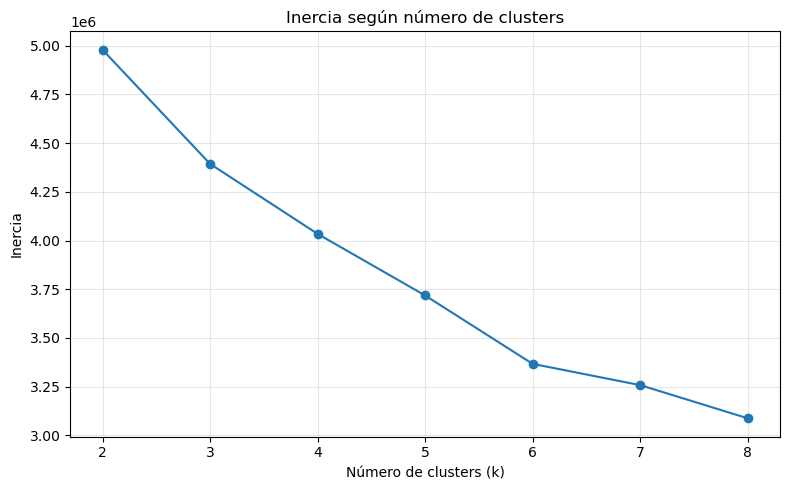

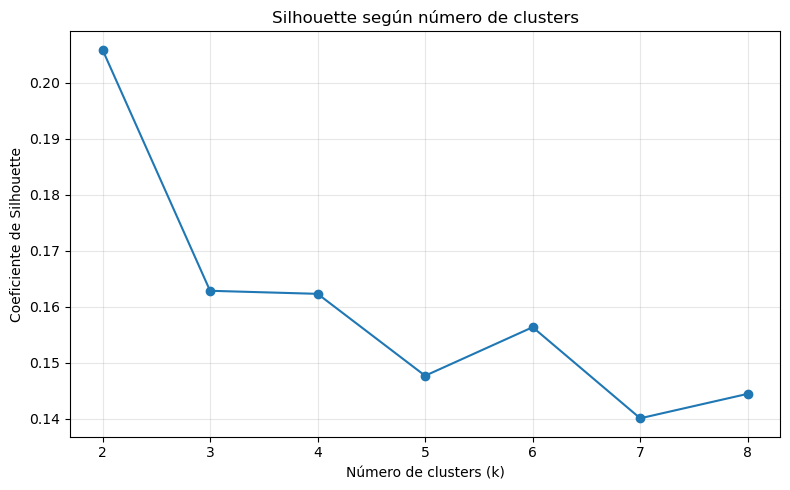

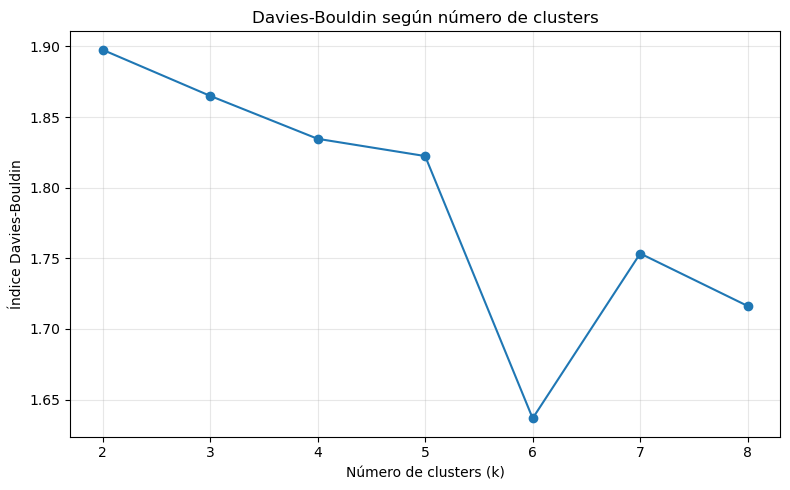

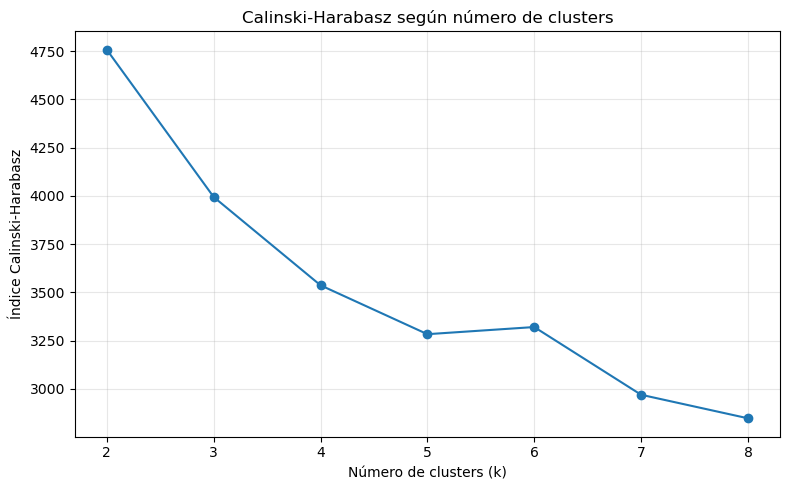

In [12]:
# ============================================================
# 4.2 VISUALIZACIÓN DE MÉTRICAS POR NÚMERO DE CLUSTERS
# ============================================================

# ----- Inercia -----

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_df["k"],
    resultados_df["Inercia"],
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Inercia según número de clusters")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ----- Silhouette -----

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_df["k"],
    resultados_df["Silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Coeficiente de Silhouette")
plt.title("Silhouette según número de clusters")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ----- Davies-Bouldin -----

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_df["k"],
    resultados_df["Davies_Bouldin"],
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Índice Davies-Bouldin")
plt.title("Davies-Bouldin según número de clusters")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ----- Calinski-Harabasz -----

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_df["k"],
    resultados_df["Calinski_Harabasz"],
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Índice Calinski-Harabasz")
plt.title("Calinski-Harabasz según número de clusters")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 4.3 ANÁLISIS DE ESTABILIDAD
# ============================================================

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_rand_score
import pandas as pd
import numpy as np
import time

candidatos_k = [2, 6]
semillas = [42, 123, 2026, 7, 99]

resultados_estabilidad = []
etiquetas_estabilidad = {}

print("=" * 70)
print("ANÁLISIS DE ESTABILIDAD DE LOS MODELOS CANDIDATOS")
print("=" * 70)

for k in candidatos_k:

    print(f"\n{'-' * 50}")
    print(f"k = {k}")
    print("-" * 50)

    etiquetas_estabilidad[k] = {}

    for semilla in semillas:

        inicio = time.perf_counter()

        modelo = MiniBatchKMeans(
            n_clusters=k,
            random_state=semilla,
            batch_size=4096,
            n_init=10
        )

        etiquetas = modelo.fit_predict(X_pca)

        tiempo = time.perf_counter() - inicio

        tamanos = np.bincount(etiquetas, minlength=k)

        resultados_estabilidad.append({
            "k": k,
            "Semilla": semilla,
            "Inercia": modelo.inertia_,
            "Tiempo_seg": tiempo,
            "Cluster_min": tamanos.min(),
            "Cluster_max": tamanos.max()
        })

        etiquetas_estabilidad[k][semilla] = etiquetas

        print(
            f"Semilla {semilla:4d} | "
            f"Inercia: {modelo.inertia_:,.2f} | "
            f"Tiempo: {tiempo:.3f} s"
        )

resultados_estabilidad_df = pd.DataFrame(
    resultados_estabilidad
)

display(resultados_estabilidad_df.round(4))

ANÁLISIS DE ESTABILIDAD DE LOS MODELOS CANDIDATOS

--------------------------------------------------
k = 2
--------------------------------------------------
Semilla   42 | Inercia: 4,979,691.89 | Tiempo: 0.255 s
Semilla  123 | Inercia: 5,274,875.27 | Tiempo: 0.302 s
Semilla 2026 | Inercia: 4,979,130.04 | Tiempo: 0.318 s
Semilla    7 | Inercia: 4,980,384.13 | Tiempo: 0.397 s
Semilla   99 | Inercia: 4,981,396.97 | Tiempo: 0.369 s

--------------------------------------------------
k = 6
--------------------------------------------------
Semilla   42 | Inercia: 3,366,447.44 | Tiempo: 0.662 s
Semilla  123 | Inercia: 3,421,888.05 | Tiempo: 0.741 s
Semilla 2026 | Inercia: 3,370,237.75 | Tiempo: 0.980 s
Semilla    7 | Inercia: 3,369,811.72 | Tiempo: 0.487 s
Semilla   99 | Inercia: 3,364,636.10 | Tiempo: 0.566 s


,k,Semilla,Inercia,Tiempo_seg,Cluster_min,Cluster_max
0,2,42,4.979692e+06,0.2549,223343,357669
1,2,123,5.274875e+06,0.3025,192258,388754
2,2,2026,4.979130e+06,0.3181,222751,358261
3,2,7,4.980384e+06,0.3969,218284,362728
4,2,99,4.981397e+06,0.3690,217522,363490
5,6,42,3.366447e+06,0.6619,48452,158407
6,6,123,3.421888e+06,0.7412,65603,162745
7,6,2026,3.370238e+06,0.9799,53380,168764
8,6,7,3.369812e+06,0.4872,50533,155048
9,6,99,3.364636e+06,0.5662,52034,168233


In [14]:
# ============================================================
# 4.4 CONCORDANCIA ENTRE SEMILLAS
# ============================================================

comparaciones = []

for k in candidatos_k:

    semillas_k = list(etiquetas_estabilidad[k].keys())

    for i in range(len(semillas_k)):
        for j in range(i + 1, len(semillas_k)):

            s1 = semillas_k[i]
            s2 = semillas_k[j]

            ari = adjusted_rand_score(
                etiquetas_estabilidad[k][s1],
                etiquetas_estabilidad[k][s2]
            )

            comparaciones.append({
                "k": k,
                "Semilla_1": s1,
                "Semilla_2": s2,
                "ARI": ari
            })

comparaciones_df = pd.DataFrame(comparaciones)

print("=" * 70)
print("ARI ENTRE EJECUCIONES")
print("=" * 70)

display(comparaciones_df.round(4))

print("\nRESUMEN DE ESTABILIDAD:")

resumen_estabilidad = (
    comparaciones_df
    .groupby("k")["ARI"]
    .agg(["mean", "std", "min", "max"])
)

display(resumen_estabilidad.round(4))

ARI ENTRE EJECUCIONES


,k,Semilla_1,Semilla_2,ARI
0,2,42,123,0.1215
1,2,42,2026,0.9956
2,2,42,7,0.9653
3,2,42,99,0.9601
4,2,123,2026,0.1199
5,2,123,7,0.1088
6,2,123,99,0.1068
7,2,2026,7,0.9694
8,2,2026,99,0.9641
9,2,7,99,0.9933



RESUMEN DE ESTABILIDAD:


,mean,std,min,max
k,,,,
2,0.6305,0.4445,0.1068,0.9956
6,0.7852,0.0889,0.6485,0.8883


### Selección preliminar del número de grupos

La evaluación interna mostró resultados diferentes según la métrica
considerada. La configuración con k=2 obtuvo el mayor coeficiente de
silueta (0.2059) y el mayor índice de Calinski-Harabasz (4757.09).
Sin embargo, presentó una estabilidad limitada ante cambios en la
semilla de inicialización.

Para k=2, el índice de Rand ajustado (ARI) entre diferentes ejecuciones
presentó una media de 0.6305, una desviación estándar de 0.4445 y un
valor mínimo de 0.1068. Esto indica que algunas inicializaciones
produjeron particiones considerablemente diferentes.

Por otro lado, k=6 obtuvo el menor índice Davies-Bouldin (1.6367) entre
las configuraciones evaluadas y mostró una estabilidad superior. El ARI
medio entre ejecuciones fue de 0.7852, con una desviación estándar de
0.0889 y un mínimo de 0.6485.

Por lo tanto, se selecciona preliminarmente k=6, ya que ofrece un mejor
equilibrio entre separación de los grupos, reducción de la inercia y
estabilidad frente a diferentes inicializaciones. La selección no se
basa en una sola métrica, sino en la interpretación conjunta de los
criterios de validación interna y estabilidad.

In [15]:
# ============================================================
# 4.5 SELECCIÓN DE LA EJECUCIÓN FINAL PARA k = 6
# ============================================================

resultados_k6 = resultados_estabilidad_df[
    resultados_estabilidad_df["k"] == 6
].copy()

display(
    resultados_k6
    .sort_values("Inercia")
    .round(4)
)

mejor_fila = resultados_k6.loc[
    resultados_k6["Inercia"].idxmin()
]

mejor_semilla = int(mejor_fila["Semilla"])

print("=" * 60)
print("CONFIGURACIÓN SELECCIONADA")
print("=" * 60)

print(f"\nNúmero de clusters: 6")
print(f"Mejor semilla: {mejor_semilla}")
print(f"Inercia: {mejor_fila['Inercia']:,.2f}")
print(f"Tiempo: {mejor_fila['Tiempo_seg']:.4f} segundos")
print(f"Cluster más pequeño: {int(mejor_fila['Cluster_min']):,}")
print(f"Cluster más grande: {int(mejor_fila['Cluster_max']):,}")

,k,Semilla,Inercia,Tiempo_seg,Cluster_min,Cluster_max
9,6,99,3.364636e+06,0.5662,52034,168233
5,6,42,3.366447e+06,0.6619,48452,158407
8,6,7,3.369812e+06,0.4872,50533,155048
7,6,2026,3.370238e+06,0.9799,53380,168764
6,6,123,3.421888e+06,0.7412,65603,162745


CONFIGURACIÓN SELECCIONADA

Número de clusters: 6
Mejor semilla: 99
Inercia: 3,364,636.10
Tiempo: 0.5662 segundos
Cluster más pequeño: 52,034
Cluster más grande: 168,233


In [16]:
# ============================================================
# 4.6 MODELO FINAL PCA + MINIBATCH K-MEANS
# ============================================================

modelo_final = MiniBatchKMeans(
    n_clusters=6,
    random_state=mejor_semilla,
    batch_size=4096,
    n_init=10
)

labels_final = modelo_final.fit_predict(X_pca)

print("=" * 60)
print("MODELO FINAL")
print("=" * 60)

print("\nConfiguración:")
print("PCA:", X_reference.shape[1], "→", X_pca.shape[1], "componentes")
print("Varianza conservada:", f"{varianza_pca * 100:.2f}%")
print("Número de clusters:", modelo_final.n_clusters)
print("Semilla:", mejor_semilla)
print("Inercia:", f"{modelo_final.inertia_:,.2f}")

print("\nTamaño de los clusters:")

tamanos_finales = pd.Series(
    labels_final
).value_counts().sort_index()

tabla_tamanos = pd.DataFrame({
    "Cluster": tamanos_finales.index,
    "Registros": tamanos_finales.values,
    "Porcentaje": (
        tamanos_finales.values / len(labels_final) * 100
    )
})

display(tabla_tamanos.round(2))

print(
    "\nTotal:",
    tabla_tamanos["Registros"].sum()
)

MODELO FINAL

Configuración:
PCA: 54 → 10 componentes
Varianza conservada: 92.24%
Número de clusters: 6
Semilla: 99
Inercia: 3,364,636.10

Tamaño de los clusters:


,Cluster,Registros,Porcentaje
0,0,168233,28.96
1,1,127299,21.91
2,2,52034,8.96
3,3,58535,10.07
4,4,75512,13.00
5,5,99399,17.11



Total: 581012


In [17]:
# ============================================================
# 5.1 MODELO DE REFERENCIA SIN PCA
# ============================================================

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import numpy as np
import time

inicio_ref = time.perf_counter()

modelo_sin_pca = MiniBatchKMeans(
    n_clusters=6,
    random_state=mejor_semilla,
    batch_size=4096,
    n_init=10
)

labels_sin_pca = modelo_sin_pca.fit_predict(X_reference)

tiempo_sin_pca = time.perf_counter() - inicio_ref

# Utilizamos EXACTAMENTE la misma muestra de 20,000 registros
# que usamos anteriormente.
X_ref_metricas = X_reference.iloc[indices_muestra]

labels_ref_muestra = labels_sin_pca[indices_muestra]

silhouette_sin_pca = silhouette_score(
    X_ref_metricas,
    labels_ref_muestra
)

davies_sin_pca = davies_bouldin_score(
    X_ref_metricas,
    labels_ref_muestra
)

calinski_sin_pca = calinski_harabasz_score(
    X_ref_metricas,
    labels_ref_muestra
)

tamanos_sin_pca = np.bincount(
    labels_sin_pca,
    minlength=6
)

print("=" * 60)
print("MODELO DE REFERENCIA SIN PCA")
print("=" * 60)

print(f"\nDimensiones: {X_reference.shape}")
print(f"Clusters: 6")
print(f"Semilla: {mejor_semilla}")

print(f"\nInercia: {modelo_sin_pca.inertia_:,.2f}")
print(f"Silhouette: {silhouette_sin_pca:.4f}")
print(f"Davies-Bouldin: {davies_sin_pca:.4f}")
print(f"Calinski-Harabasz: {calinski_sin_pca:,.2f}")

print(f"\nTiempo de entrenamiento: {tiempo_sin_pca:.4f} segundos")
print(f"Memoria de representación: {memoria_reference_mb:.2f} MB")

print("\nTamaños de los clusters:")
print(tamanos_sin_pca)

print("\nTotal:", tamanos_sin_pca.sum())

MODELO DE REFERENCIA SIN PCA

Dimensiones: (581012, 54)
Clusters: 6
Semilla: 99

Inercia: 3,897,648.39
Silhouette: 0.1419
Davies-Bouldin: 1.7584
Calinski-Harabasz: 2,862.31

Tiempo de entrenamiento: 2.1689 segundos
Memoria de representación: 239.37 MB

Tamaños de los clusters:
[ 64231 180076 126012  72451  48531  89711]

Total: 581012


In [18]:
# ============================================================
# 5.2 MÉTRICAS DEL MODELO FINAL CON PCA
# ============================================================

X_pca_metricas = X_pca.iloc[indices_muestra]

labels_pca_muestra = labels_final[indices_muestra]

silhouette_pca = silhouette_score(
    X_pca_metricas,
    labels_pca_muestra
)

davies_pca = davies_bouldin_score(
    X_pca_metricas,
    labels_pca_muestra
)

calinski_pca = calinski_harabasz_score(
    X_pca_metricas,
    labels_pca_muestra
)

print("=" * 60)
print("MÉTRICAS DEL MODELO FINAL CON PCA")
print("=" * 60)

print(f"\nSilhouette: {silhouette_pca:.4f}")
print(f"Davies-Bouldin: {davies_pca:.4f}")
print(f"Calinski-Harabasz: {calinski_pca:,.2f}")

MÉTRICAS DEL MODELO FINAL CON PCA

Silhouette: 0.1588
Davies-Bouldin: 1.6321
Calinski-Harabasz: 3,322.18


In [19]:
# ============================================================
# 5.3 COMPARACIÓN PCA VS. SIN PCA
# ============================================================

comparacion_modelos = pd.DataFrame({
    "Configuración": [
        "Sin PCA",
        "PCA (10 componentes)"
    ],
    "Dimensiones": [
        X_reference.shape[1],
        X_pca.shape[1]
    ],
    "Memoria_MB": [
        memoria_reference_mb,
        memoria_pca_mb
    ],
    "Silhouette": [
        silhouette_sin_pca,
        silhouette_pca
    ],
    "Davies_Bouldin": [
        davies_sin_pca,
        davies_pca
    ],
    "Calinski_Harabasz": [
        calinski_sin_pca,
        calinski_pca
    ],
    "Inercia": [
        modelo_sin_pca.inertia_,
        modelo_final.inertia_
    ]
})

display(comparacion_modelos.round(4))

,Configuración,Dimensiones,Memoria_MB,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia
0,Sin PCA,54,239.3697,0.1419,1.7584,2862.311,3.897648e+06
1,PCA (10 componentes),10,44.3278,0.1588,1.6321,3322.184,3.364636e+06


In [20]:
# ============================================================
# 5.4 ESTABILIDAD DE LA CONFIGURACIÓN SIN PCA
# ============================================================

from sklearn.metrics import adjusted_rand_score

labels_ref_semillas = {}

for semilla in semillas:

    modelo_temp = MiniBatchKMeans(
        n_clusters=6,
        random_state=semilla,
        batch_size=4096,
        n_init=10
    )

    labels_temp = modelo_temp.fit_predict(X_reference)

    labels_ref_semillas[semilla] = labels_temp


ari_ref = []

for i in range(len(semillas)):
    for j in range(i + 1, len(semillas)):

        ari = adjusted_rand_score(
            labels_ref_semillas[semillas[i]],
            labels_ref_semillas[semillas[j]]
        )

        ari_ref.append(ari)


print("=" * 60)
print("ESTABILIDAD SIN PCA")
print("=" * 60)

print(f"\nARI medio: {np.mean(ari_ref):.4f}")
print(f"Desviación estándar: {np.std(ari_ref, ddof=1):.4f}")
print(f"ARI mínimo: {np.min(ari_ref):.4f}")
print(f"ARI máximo: {np.max(ari_ref):.4f}")

print("\nComparación:")
print("PCA k=6      -> ARI medio: 0.7852")
print(f"Sin PCA k=6  -> ARI medio: {np.mean(ari_ref):.4f}")

ESTABILIDAD SIN PCA

ARI medio: 0.5808
Desviación estándar: 0.1557
ARI mínimo: 0.3531
ARI máximo: 0.8010

Comparación:
PCA k=6      -> ARI medio: 0.7852
Sin PCA k=6  -> ARI medio: 0.5808


In [21]:
# ============================================================
# 5.6 VALIDACIÓN EXTERNA DEL MODELO FINAL
# ============================================================

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

print("=" * 65)
print("VALIDACIÓN EXTERNA DEL MODELO FINAL")
print("=" * 65)

# Verificar dimensiones
assert len(labels_final) == len(y_external)

# Índice de Rand ajustado
ari_externo = adjusted_rand_score(
    y_external,
    labels_final
)

# Información mutua normalizada
nmi_externo = normalized_mutual_info_score(
    y_external,
    labels_final
)

print("\nConfiguración seleccionada:")
print("Algoritmo: MiniBatch K-Means")
print("Componentes PCA:", n_components_selected)
print("Número de clusters:", modelo_final.n_clusters)
print("Semilla:", mejor_semilla)

print("\nRESULTADOS DE VALIDACIÓN EXTERNA")
print(f"Adjusted Rand Index (ARI): {ari_externo:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi_externo:.4f}")

print("\nValidación completada.")

VALIDACIÓN EXTERNA DEL MODELO FINAL

Configuración seleccionada:
Algoritmo: MiniBatch K-Means
Componentes PCA: 10
Número de clusters: 6
Semilla: 99

RESULTADOS DE VALIDACIÓN EXTERNA
Adjusted Rand Index (ARI): 0.0251
Normalized Mutual Information (NMI): 0.0561

Validación completada.


In [22]:
# ============================================================
# 5.7 CORRESPONDENCIA ENTRE CLUSTERS Y COVER_TYPE
# ============================================================

tabla_correspondencia = pd.crosstab(
    pd.Series(labels_final, name="Cluster"),
    pd.Series(y_external.to_numpy(), name="Cover_Type")
)

print("=" * 65)
print("CORRESPONDENCIA ENTRE CLUSTERS Y CLASES CONOCIDAS")
print("=" * 65)

display(tabla_correspondencia)

# Porcentaje de cada clase dentro de cada cluster
tabla_porcentajes = pd.crosstab(
    pd.Series(labels_final, name="Cluster"),
    pd.Series(y_external.to_numpy(), name="Cover_Type"),
    normalize="index"
) * 100

print("\nPORCENTAJE DE CLASES DENTRO DE CADA CLUSTER")

display(tabla_porcentajes.round(2))

CORRESPONDENCIA ENTRE CLUSTERS Y CLASES CONOCIDAS


Cover_Type,1,2,3,4,5,6,7
Cluster,,,,,,,
0,58703,88212,8579,835,3348,3627,4929
1,58417,58657,2701,161,1707,1266,4390
2,10237,21306,12175,357,468,7126,365
3,24822,25820,1059,35,602,120,6077
4,20226,32063,11240,1359,3067,5228,2329
5,39435,57243,0,0,301,0,2420



PORCENTAJE DE CLASES DENTRO DE CADA CLUSTER


Cover_Type,1,2,3,4,5,6,7
Cluster,,,,,,,
0,34.89,52.43,5.10,0.50,1.99,2.16,2.93
1,45.89,46.08,2.12,0.13,1.34,0.99,3.45
2,19.67,40.95,23.40,0.69,0.90,13.69,0.70
3,42.41,44.11,1.81,0.06,1.03,0.21,10.38
4,26.79,42.46,14.89,1.80,4.06,6.92,3.08
5,39.67,57.59,0.00,0.00,0.30,0.00,2.43


### Comparación de configuraciones y selección final

Se compararon dos configuraciones de MiniBatch K-Means con seis
grupos: una basada en las 54 características procesadas y otra
reducida a 10 componentes principales mediante PCA.

La configuración con PCA obtuvo mejores resultados en las
tres métricas internas evaluadas:

- Silhouette: 0.1588 frente a 0.1419.
- Davies-Bouldin: 1.6321 frente a 1.7584.
- Calinski-Harabasz: 3322.18 frente a 2862.31.

También presentó mayor estabilidad ante cambios en la semilla,
con un ARI medio entre ejecuciones de 0.7852 frente a 0.5808
para la configuración sin PCA.

La representación PCA redujo el almacenamiento de las
características de 239.37 MB a 44.33 MB, conservando el
92.24 % de la varianza explicada.

Se seleccionó MiniBatch K-Means con seis grupos, diez
componentes principales y semilla 99.

Aunque esta configuración presentó mejores resultados
comparativos, el coeficiente de silueta indica que la
separación de los grupos es limitada.

La validación externa mediante Cover_Type se realiza
únicamente después de seleccionar la configuración final.

### Validación externa mediante `Cover_Type`

Después de seleccionar la configuración final sin utilizar la variable
`Cover_Type`, se realizó una validación externa para determinar el grado
de correspondencia entre los grupos obtenidos y las clases conocidas de
cobertura forestal.

El índice de Rand ajustado (ARI) obtenido fue de 0.0251 y la información
mutua normalizada (NMI) fue de 0.0561. Ambos valores indican una
correspondencia baja entre los seis clusters identificados mediante
MiniBatch K-Means y las siete categorías de `Cover_Type`.

La tabla de contingencia confirma que los clusters no corresponden de
forma directa a una única clase de cobertura. Por ejemplo, el cluster 5
está compuesto principalmente por las clases 2 (57.59 %) y 1 (39.67 %),
mientras que el cluster 2 presenta una composición más heterogénea, con
presencia importante de las clases 2, 3, 1 y 6.

Estos resultados no invalidan necesariamente la existencia de estructura
en las características cartográficas. El agrupamiento fue construido sin
información sobre `Cover_Type` y, por lo tanto, identifica similitudes
geométricas en el espacio de características que no necesariamente
coinciden con las categorías conocidas de cobertura.

La utilización de `Cover_Type` en esta etapa constituye únicamente una
validación externa y no transforma el procedimiento en un problema de
clasificación. El modelo continúa siendo un método de aprendizaje no
supervisado.

En consecuencia, los clusters no deben interpretarse como sustitutos de
las clases de cobertura forestal ni como categorías naturales o
definitivas. Su utilidad debe evaluarse a partir de los perfiles
cartográficos que caracterizan cada grupo.

In [23]:
# ============================================================
# 5.10 PERFILES DE LOS CLUSTERS
# Variables cuantitativas originales
# ============================================================

# Copia de las variables originales
df_perfiles = X.copy()

# Incorporar solamente las etiquetas finales
df_perfiles["Cluster"] = labels_final

# Perfil promedio de las variables cuantitativas
perfiles_cuantitativos = (
    df_perfiles
    .groupby("Cluster")[quantitative_cols]
    .mean()
)

print("=" * 70)
print("PERFILES PROMEDIO DE LOS CLUSTERS")
print("=" * 70)

display(perfiles_cuantitativos.round(2))

PERFILES PROMEDIO DE LOS CLUSTERS


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
Cluster,,,,,,,,,,
0,2933.58,82.99,10.78,192.63,19.40,1737.33,227.24,225.49,129.56,1755.94
1,3052.31,283.39,11.87,237.95,30.54,2483.35,196.92,236.45,176.32,1567.15
2,2688.96,300.93,24.69,225.38,72.64,1506.16,156.54,217.68,193.79,1317.17
3,3174.34,140.43,14.31,654.49,150.12,2173.25,215.36,225.61,141.30,1875.12
4,2792.80,65.99,23.37,224.56,55.42,1531.96,226.61,192.16,85.29,1477.67
5,3025.47,116.10,9.90,270.12,30.85,4384.30,222.33,228.10,138.57,3680.01


In [24]:
# ============================================================
# 5.11 PERFILES RELATIVOS ESTANDARIZADOS
# ============================================================

medias_globales = X[quantitative_cols].mean()
desviaciones_globales = X[quantitative_cols].std()

perfiles_z = (
    perfiles_cuantitativos - medias_globales
) / desviaciones_globales

print("=" * 70)
print("PERFILES RELATIVOS DE LOS CLUSTERS")
print("=" * 70)

display(perfiles_z.round(2))

PERFILES RELATIVOS DE LOS CLUSTERS


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
Cluster,,,,,,,,,,
0,-0.09,-0.65,-0.44,-0.36,-0.46,-0.39,0.56,0.11,-0.34,-0.17
1,0.33,1.14,-0.30,-0.15,-0.27,0.09,-0.57,0.66,0.88,-0.31
2,-0.97,1.30,1.41,-0.21,0.45,-0.54,-2.08,-0.29,1.34,-0.50
3,0.77,-0.14,0.03,1.81,1.78,-0.11,0.12,0.12,-0.03,-0.08
4,-0.59,-0.80,1.24,-0.21,0.15,-0.52,0.54,-1.58,-1.50,-0.38
5,0.24,-0.35,-0.56,0.00,-0.27,1.30,0.38,0.24,-0.10,1.28


In [25]:
# ============================================================
# 5.12 VARIABLES BINARIAS PREDOMINANTES POR CLUSTER
# ============================================================

perfiles_binarios = (
    df_perfiles
    .groupby("Cluster")[binary_cols]
    .mean()
)

print("=" * 70)
print("INDICADORES BINARIOS PREDOMINANTES POR CLUSTER")
print("=" * 70)

for cluster in perfiles_binarios.index:

    print(f"\nCLUSTER {cluster}")
    print("-" * 40)

    principales = (
        perfiles_binarios.loc[cluster]
        .sort_values(ascending=False)
        .head(5)
    )

    for variable, proporcion in principales.items():
        print(
            f"{variable:<30} "
            f"{proporcion * 100:>6.2f}%"
        )

INDICADORES BINARIOS PREDOMINANTES POR CLUSTER

CLUSTER 0
----------------------------------------
Wilderness_Area_0               45.85%
Wilderness_Area_2               44.89%
Soil_Type_28                    17.13%
Soil_Type_22                    14.22%
Soil_Type_31                    10.10%

CLUSTER 1
----------------------------------------
Wilderness_Area_2               57.02%
Wilderness_Area_0               33.42%
Soil_Type_31                    17.23%
Soil_Type_22                    15.87%
Soil_Type_28                    14.82%

CLUSTER 2
----------------------------------------
Wilderness_Area_2               48.11%
Wilderness_Area_3               32.41%
Soil_Type_9                     27.40%
Wilderness_Area_0               16.23%
Soil_Type_32                    13.96%

CLUSTER 3
----------------------------------------
Wilderness_Area_2               71.84%
Wilderness_Area_0               18.94%
Soil_Type_31                    18.89%
Soil_Type_32                    17.64%
Soil

### Caracterización e interpretación de los clusters

Los seis grupos obtenidos presentan diferencias en sus características
cartográficas originales. Para facilitar su interpretación se analizaron
las medias de las variables cuantitativas, sus valores relativos respecto
al conjunto completo y la prevalencia de las variables binarias.

**Cluster 0 – Terreno moderado y accesible.**
Presenta elevación ligeramente inferior al promedio (-0.09), pendiente
relativamente baja (-0.44) y distancias inferiores al promedio respecto
a hidrología, carreteras y puntos de fuego. Destaca además un valor
relativamente alto de Hillshade_9am (0.56). Las áreas Wilderness_Area_0
y Wilderness_Area_2 representan aproximadamente 45.85 % y 44.89 %,
respectivamente.

**Cluster 1 – Terreno elevado de orientación occidental.**
Presenta elevación superior al promedio (0.33), pendiente relativamente
baja (-0.30) y un valor elevado de Aspect (1.14). También destaca por
Hillshade_3pm (0.88). Wilderness_Area_2 es el indicador binario
predominante, con 57.02 %.

**Cluster 2 – Terreno bajo y escarpado.**
Es uno de los grupos más diferenciados. Presenta elevación muy inferior
al promedio (-0.97), pendiente considerablemente superior (1.41) y
distancia vertical a la hidrología por encima del promedio (0.45).
Además, Hillshade_9am alcanza un valor relativo de -2.08 y Hillshade_3pm
de 1.34. Wilderness_Area_2 representa 48.11 % y Wilderness_Area_3
32.41 %.

**Cluster 3 – Terreno elevado alejado de hidrología.**
Presenta la mayor elevación relativa (0.77) y se distingue especialmente
por sus distancias horizontal (1.81) y vertical (1.78) respecto a la
hidrología. Wilderness_Area_2 concentra 71.84 % de sus observaciones.

**Cluster 4 – Terreno bajo, inclinado y sombreado.**
Presenta elevación inferior al promedio (-0.59) y pendiente elevada
(1.24). También destacan los valores reducidos de Hillshade_Noon (-1.58)
y Hillshade_3pm (-1.50), así como una distancia a carreteras inferior al
promedio (-0.52). Wilderness_Area_2 representa 47.80 % de las
observaciones.

**Cluster 5 – Terreno remoto de Wilderness Area 0.**
Presenta pendiente relativamente baja (-0.56) y se distingue por sus
grandes distancias respecto a carreteras (1.30) y puntos de fuego (1.28).
El 97.17 % de sus observaciones corresponden a Wilderness_Area_0,
constituyendo el patrón binario más definido entre los grupos.

Los nombres asignados tienen únicamente una finalidad descriptiva y se
basan en las características cartográficas predominantes. No representan
categorías naturales, definitivas ni equivalentes a `Cover_Type`.

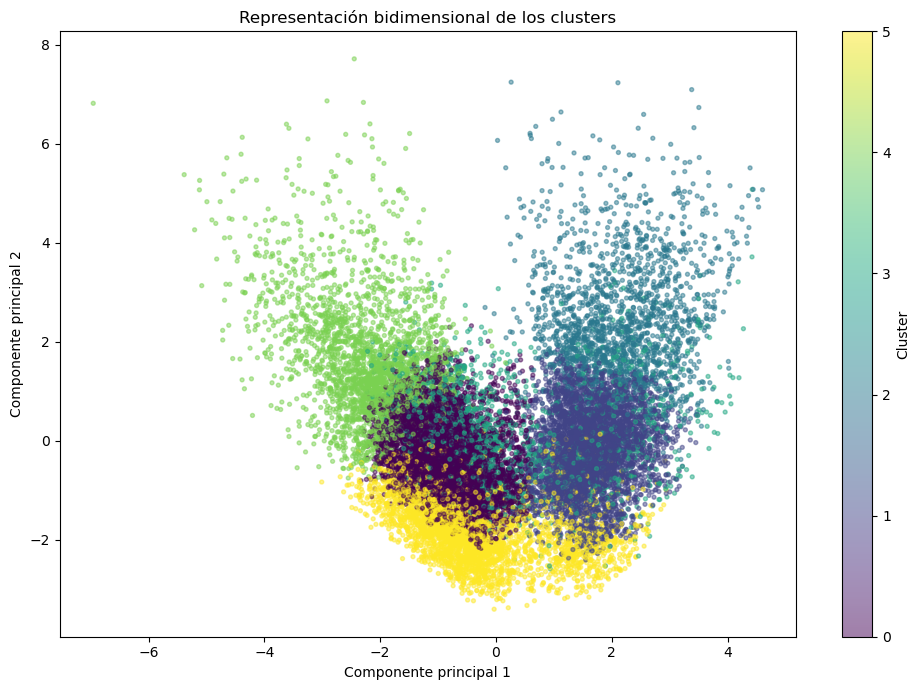

In [26]:
# ============================================================
# 5.13 REPRESENTACIÓN BIDIMENSIONAL DE LOS CLUSTERS
# ============================================================

import matplotlib.pyplot as plt

muestra_plot = X_pca.iloc[indices_muestra].copy()
labels_plot = labels_final[indices_muestra]

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    muestra_plot["PC1"],
    muestra_plot["PC2"],
    c=labels_plot,
    s=8,
    alpha=0.5
)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Representación bidimensional de los clusters")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.tight_layout()
plt.show()

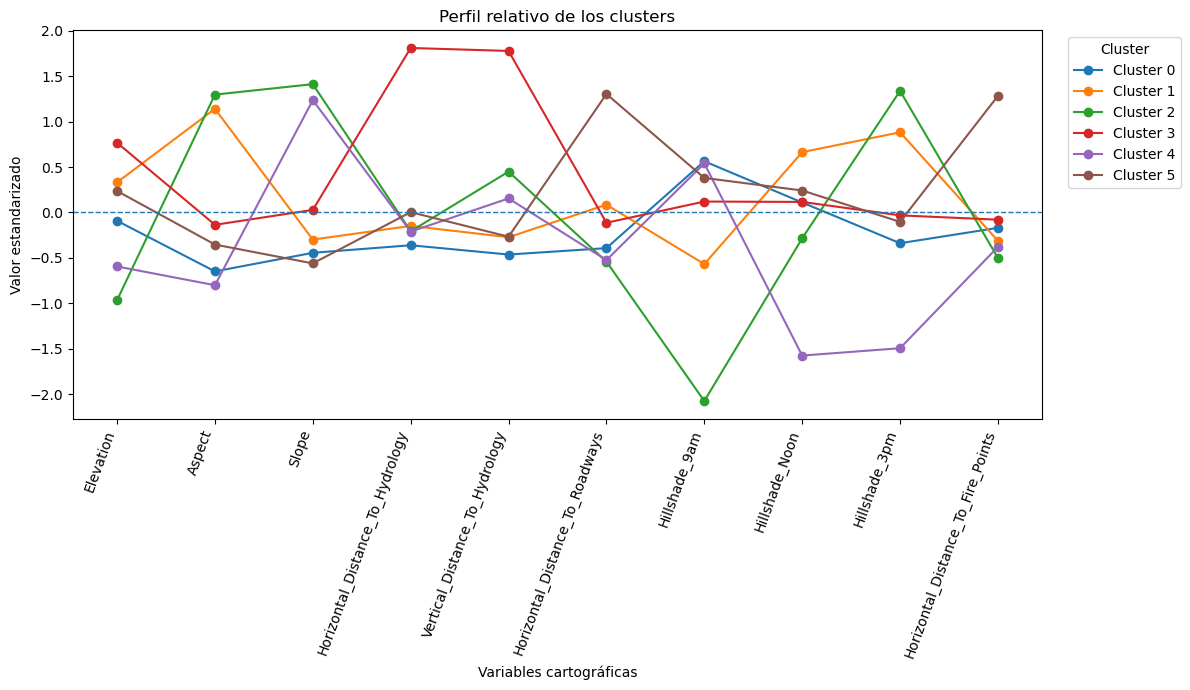

In [27]:
# ============================================================
# 5.14 PERFILES ESTANDARIZADOS DE LOS CLUSTERS
# ============================================================

plt.figure(figsize=(12, 7))

for cluster in perfiles_z.index:
    plt.plot(
        quantitative_cols,
        perfiles_z.loc[cluster],
        marker="o",
        label=f"Cluster {cluster}"
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Variables cartográficas")
plt.ylabel("Valor estandarizado")
plt.title("Perfil relativo de los clusters")

plt.xticks(
    rotation=70,
    ha="right"
)

plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Interpretación de las visualizaciones

La representación bidimensional mediante los dos primeros componentes
principales muestra que existen regiones diferenciadas entre algunos
clusters, aunque también se observa un solapamiento considerable,
especialmente en la zona central.

Este comportamiento es consistente con el coeficiente de silueta
obtenido (0.1588), que indica una separación limitada entre los grupos.
Sin embargo, esta visualización representa únicamente los dos primeros
componentes principales, mientras que el modelo final utiliza diez,
por lo que constituye una proyección parcial de la estructura utilizada
durante el agrupamiento.

La visualización de perfiles estandarizados permite identificar las
principales características que diferencian a los grupos. El cluster 2
destaca por su mayor pendiente y menor Hillshade_9am; el cluster 3 por
sus elevadas distancias horizontal y vertical respecto a la hidrología;
el cluster 4 por pendiente elevada y valores reducidos de
Hillshade_Noon y Hillshade_3pm; y el cluster 5 por sus grandes
distancias respecto a carreteras y puntos de fuego.

En conjunto, las visualizaciones muestran que los clusters poseen
perfiles cartográficos diferenciados, aunque sus fronteras no son
completamente definidas. Por ello, los grupos se interpretan como
segmentaciones descriptivas y no como categorías naturales o
definitivas.

In [28]:
# ============================================================
# 5.15 SENSIBILIDAD AL NÚMERO DE COMPONENTES PCA
# ============================================================

from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import pandas as pd
import numpy as np
import time

componentes_prueba = [7, 10, 14]

resultados_componentes = []

for n_comp in componentes_prueba:

    print("=" * 60)
    print(f"Evaluando PCA con {n_comp} componentes")
    print("=" * 60)

    # PCA
    inicio_pca = time.perf_counter()

    pca_temp = PCA(
        n_components=n_comp,
        random_state=42
    )

    X_temp = pca_temp.fit_transform(X_reference)

    tiempo_pca = time.perf_counter() - inicio_pca

    # MiniBatch K-Means
    inicio_kmeans = time.perf_counter()

    modelo_temp = MiniBatchKMeans(
        n_clusters=6,
        random_state=99,
        batch_size=4096,
        n_init=10
    )

    labels_temp = modelo_temp.fit_predict(X_temp)

    tiempo_kmeans = time.perf_counter() - inicio_kmeans

    # Misma muestra utilizada anteriormente
    X_temp_muestra = X_temp[indices_muestra]
    labels_temp_muestra = labels_temp[indices_muestra]

    silhouette = silhouette_score(
        X_temp_muestra,
        labels_temp_muestra
    )

    davies = davies_bouldin_score(
        X_temp_muestra,
        labels_temp_muestra
    )

    calinski = calinski_harabasz_score(
        X_temp_muestra,
        labels_temp_muestra
    )

    resultados_componentes.append({
        "Componentes": n_comp,
        "Varianza_explicada": pca_temp.explained_variance_ratio_.sum(),
        "Silhouette": silhouette,
        "Davies_Bouldin": davies,
        "Calinski_Harabasz": calinski,
        "Inercia": modelo_temp.inertia_,
        "Tiempo_PCA_seg": tiempo_pca,
        "Tiempo_KMeans_seg": tiempo_kmeans
    })


sensibilidad_componentes = pd.DataFrame(
    resultados_componentes
)

print("\n" + "=" * 70)
print("RESUMEN DE SENSIBILIDAD AL NÚMERO DE COMPONENTES")
print("=" * 70)

display(
    sensibilidad_componentes.round(4)
)

Evaluando PCA con 7 componentes
Evaluando PCA con 10 componentes
Evaluando PCA con 14 componentes

RESUMEN DE SENSIBILIDAD AL NÚMERO DE COMPONENTES


,Componentes,Varianza_explicada,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Tiempo_PCA_seg,Tiempo_KMeans_seg
0,7,0.8346,0.1787,1.5308,3819.9211,2.866059e+06,0.4977,0.8240
1,10,0.9224,0.1588,1.6321,3322.1840,3.364636e+06,0.3606,0.3969
2,14,0.9551,0.1351,1.8640,2805.6269,3.744925e+06,0.3269,0.4511


In [29]:
# ============================================================
# 5.16 ESTABILIDAD SEGÚN NÚMERO DE COMPONENTES
# ============================================================

from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_rand_score

import pandas as pd
import numpy as np

componentes_estabilidad = [7, 10, 14]
semillas_estabilidad = [42, 123, 2026, 7, 99]

resultados_estabilidad_componentes = []

for n_comp in componentes_estabilidad:

    print("=" * 60)
    print(f"PCA con {n_comp} componentes")
    print("=" * 60)

    # Crear representación PCA
    pca_temp = PCA(
        n_components=n_comp,
        random_state=42
    )

    X_temp = pca_temp.fit_transform(X_reference)

    etiquetas_semillas = {}

    # Ajustar modelo con diferentes semillas
    for semilla in semillas_estabilidad:

        modelo_temp = MiniBatchKMeans(
            n_clusters=6,
            random_state=semilla,
            batch_size=4096,
            n_init=10
        )

        etiquetas_temp = modelo_temp.fit_predict(X_temp)

        etiquetas_semillas[semilla] = etiquetas_temp

    # ARI entre todos los pares de semillas
    valores_ari = []

    for i in range(len(semillas_estabilidad)):
        for j in range(i + 1, len(semillas_estabilidad)):

            s1 = semillas_estabilidad[i]
            s2 = semillas_estabilidad[j]

            ari = adjusted_rand_score(
                etiquetas_semillas[s1],
                etiquetas_semillas[s2]
            )

            valores_ari.append(ari)

    resultados_estabilidad_componentes.append({
        "Componentes": n_comp,
        "Varianza_explicada": (
            pca_temp.explained_variance_ratio_.sum()
        ),
        "ARI_medio": np.mean(valores_ari),
        "ARI_std": np.std(valores_ari, ddof=1),
        "ARI_min": np.min(valores_ari),
        "ARI_max": np.max(valores_ari)
    })


estabilidad_componentes_df = pd.DataFrame(
    resultados_estabilidad_componentes
)

print("\n" + "=" * 70)
print("ESTABILIDAD SEGÚN NÚMERO DE COMPONENTES")
print("=" * 70)

display(
    estabilidad_componentes_df.round(4)
)

PCA con 7 componentes
PCA con 10 componentes
PCA con 14 componentes

ESTABILIDAD SEGÚN NÚMERO DE COMPONENTES


,Componentes,Varianza_explicada,ARI_medio,ARI_std,ARI_min,ARI_max
0,7,0.8346,0.4664,0.0816,0.3459,0.6074
1,10,0.9224,0.7852,0.0889,0.6485,0.8883
2,14,0.9551,0.5390,0.1291,0.3567,0.7187


### Sensibilidad al número de componentes principales

Se evaluó la sensibilidad del agrupamiento utilizando 7, 10 y 14
componentes principales. Estas configuraciones conservaron aproximadamente
83.46 %, 92.24 % y 95.51 % de la varianza, respectivamente.

La representación de siete componentes obtuvo los mejores indicadores
internos, con un coeficiente Silhouette de 0.1787, un índice
Davies-Bouldin de 1.5308 y un índice Calinski-Harabasz de 3819.92.

Con diez componentes se obtuvo un Silhouette de 0.1588,
Davies-Bouldin de 1.6321 y Calinski-Harabasz de 3322.18, conservando
el 92.24 % de la varianza original.

La configuración de catorce componentes conservó el mayor porcentaje
de varianza (95.51 %), pero presentó los resultados menos favorables
en las tres métricas internas evaluadas.

Los resultados muestran que conservar una mayor proporción de varianza
no implica necesariamente una mejor estructura para el agrupamiento.
Parte de la variabilidad incorporada por componentes adicionales puede
no contribuir a una mayor separación entre los grupos.

La configuración de diez componentes fue seleccionada originalmente
mediante un criterio previo de conservación de aproximadamente el
90 % de la varianza. No obstante, el mejor desempeño interno de la
representación de siete componentes se considera en el análisis de
sensibilidad y constituye una evidencia relevante para la evaluación
crítica del modelo.

### Análisis de estabilidad y selección definitiva

El análisis de sensibilidad mostró que el número de componentes
principales afecta tanto la calidad interna como la estabilidad del
agrupamiento.

La configuración de siete componentes presentó los mejores indicadores
internos, con Silhouette de 0.1787, Davies-Bouldin de 1.5308 y
Calinski-Harabasz de 3819.92. Sin embargo, su estabilidad ante cambios
en la semilla fue limitada, obteniendo un ARI medio de 0.4664 y un
mínimo de 0.3459.

La configuración de diez componentes conservó el 92.24 % de la
varianza y obtuvo un ARI medio entre ejecuciones de 0.7852, con un
mínimo de 0.6485. Esto representa una estabilidad considerablemente
superior a las configuraciones de siete y catorce componentes.

La configuración de catorce componentes conservó el 95.51 % de la
varianza, pero presentó métricas internas menos favorables y un ARI
medio de estabilidad de 0.5390.

Por lo tanto, se mantiene la configuración de diez componentes como
representación final. Aunque siete componentes proporciona una mayor
separación interna, diez componentes ofrece un mejor compromiso entre
conservación de información, calidad del agrupamiento y reproducibilidad
ante cambios en la inicialización.

La configuración final utiliza PCA con diez componentes y MiniBatch
K-Means con seis grupos y semilla 99.

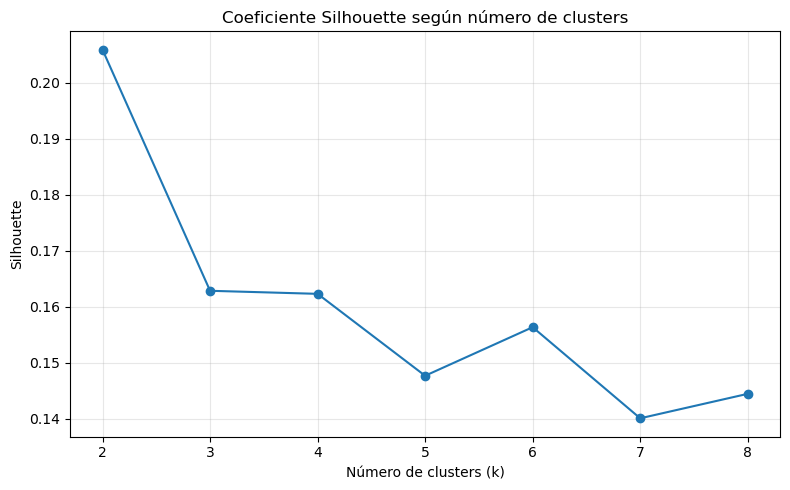

In [31]:
# ============================================================
# 5.17 COMPARACIÓN DE SILHOUETTE SEGÚN k
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_df["k"],
    resultados_df["Silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette")
plt.title("Coeficiente Silhouette según número de clusters")
plt.xticks(resultados_df["k"])
plt.grid(alpha=0.3)

plt.tight_layout()

# Guardar para el repositorio
plt.savefig(
    "silhouette_por_k.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

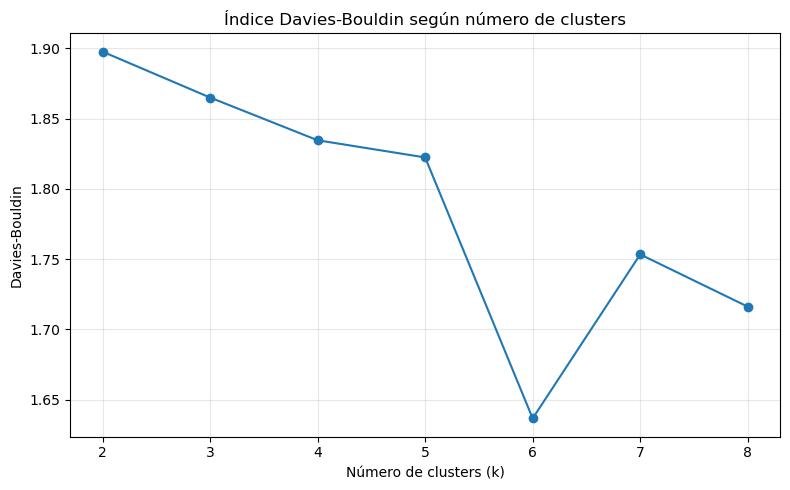

In [32]:
# ============================================================
# 5.18 DAVIES-BOULDIN SEGÚN k
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    resultados_df["k"],
    resultados_df["Davies_Bouldin"],
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Davies-Bouldin")
plt.title("Índice Davies-Bouldin según número de clusters")
plt.xticks(resultados_df["k"])
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "davies_bouldin_por_k.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
plt.savefig(
    "clusters_pca_2d.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [34]:
plt.savefig(
    "perfiles_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [35]:
import sys
import matplotlib
import numpy
import pandas
import sklearn

print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
NumPy: 2.3.5
Pandas: 2.3.3
Scikit-learn: 1.7.2
Matplotlib: 3.10.6
